In [1]:
'''
Note that this setting (dim =10, genomic mutation rate =0.01) is what we used in our further analyses.

Here we further tested the reduction of loci and dimenation # from 100 to 10. Here we scalely reduce the genomic mutation rate 
to be 0.01 (which mutaiton rate per site per generation is the same as that in 100 loci system). 

Here we compared the fitness dynamics and mutation statistics under no and universal pleiotropy with different ploidies.

Using corrected data with random.seed()

'''

'\nNote that this setting (dim =10, genomic mutation rate =0.01) is what we used in our further analyses.\n\nHere we further tested the reduction of loci and dimenation # from 100 to 10. Here we scalely reduce the genomic mutation rate \nto be 0.01 (which mutaiton rate per site per generation is the same as that in 100 loci system). \n\nHere we compared the fitness dynamics and mutation statistics under no and universal pleiotropy with different ploidies.\n\nUsing corrected data with random.seed()\n\n'

In [2]:
from __future__ import division
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [3]:
generation_list = []

for i in range(2002):
    generation_list.append(i)
    
print(len(generation_list))

2002


In [4]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_var_mean = []
    total_var_std = []
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        var_mean = []
        var_std = []
       
        fit_mean.extend(list(pd.Series(f.mFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.mFit_Std,dtype=float)))
    
        var_mean.extend(list(pd.Series(f.varFit_Mean,dtype=float)))
        var_std.extend(list(pd.Series(f.varFit_Std,dtype=float)))
    
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_var_mean.append(var_mean)
        total_var_std.append(var_std)  
        
    return total_fit_mean, total_fit_std, total_var_mean, total_var_std

## N =500_Initial fitness =0.5_Universal Pleiotropy_Different Ploidy
### 1. Fitness dynamics comparison

In [5]:
## Amitosis

In [6]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181210_Test of FGM_4_Reduce Dim to 10\Data\2.3. Universal Pley_Diff Ploidy_GMU = 0.01\Amito")

In [7]:
amito = ['Cor_UvPley_GMU001_Dim10_P1_Amito_Fit_N500_Fit05_SM005.csv', 'Cor_UvPley_GMU001_Dim10_P2_Amito_Fit_N500_Fit05_SM005.csv', \
         'Cor_UvPley_GMU001_Dim10_P4_Amito_Fit_N500_Fit05_SM005.csv', 'Cor_UvPley_GMU001_Dim10_P8_Amito_Fit_N500_Fit05_SM005.csv', \
         'Cor_UvPley_GMU001_Dim10_P16_Amito_Fit_N500_Fit05_SM005.csv',  'Cor_UvPley_GMU001_Dim10_P32_Amito_Fit_N500_Fit05_SM005.csv',\
         'Cor_UvPley_GMU001_Dim10_P45_Amito_Fit_N500_Fit05_SM005.csv', 'Cor_UvPley_GMU001_Dim10_P64_Amito_Fit_N500_Fit05_SM005.csv', \
        'Cor_UvPley_GMU001_Dim10_P128_Amito_Fit_N500_Fit05_SM005.csv']

In [8]:
m = get_data1(amito)

amito_fit_mean =m[0]
amito_fit_std = m[1]
amito_var_mean =m[2]
amito_var_std = m[3]

In [9]:
## Mitosis

In [10]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181210_Test of FGM_4_Reduce Dim to 10\Data\2.3. Universal Pley_Diff Ploidy_GMU = 0.01\Mito")

In [11]:
mito = ['Cor_UvPley_GMU001_Dim10_P1_Mito_Fit_N500_Fit05_SM005.csv', 'Cor_UvPley_GMU001_Dim10_P2_Mito_Fit_N500_Fit05_SM005.csv', \
         'Cor_UvPley_GMU001_Dim10_P4_Mito_Fit_N500_Fit05_SM005.csv', 'Cor_UvPley_GMU001_Dim10_P8_Mito_Fit_N500_Fit05_SM005.csv', \
         'Cor_UvPley_GMU001_Dim10_P16_Mito_Fit_N500_Fit05_SM005.csv',  'Cor_UvPley_GMU001_Dim10_P32_Mito_Fit_N500_Fit05_SM005.csv',\
         'Cor_UvPley_GMU001_Dim10_P45_Mito_Fit_N500_Fit05_SM005.csv', 'Cor_UvPley_GMU001_Dim10_P64_Mito_Fit_N500_Fit05_SM005.csv', \
        'Cor_UvPley_GMU001_Dim10_P128_Mito_Fit_N500_Fit05_SM005.csv']

In [12]:
s = get_data1(mito)

mito_fit_mean =s[0]
mito_fit_std = s[1]
mito_var_mean =s[2]
mito_var_std = s[3]

In [13]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 30})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(8)
    ax.spines['bottom'].set_linewidth(8)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')

### 2. Comparison with no pleiotropy

In [14]:
## No pleiotropy_Amitosis

In [15]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181210_Test of FGM_4_Reduce Dim to 10\Data\1.3. No Pley_Diff Ploidy_GMU = 0.01\Amito")

In [16]:
amito2 = ['Cor_NoPley_GMU001_Dim10_P1_Amito_Fit_N500_Fit05_SM005.csv', 'Cor_NoPley_GMU001_Dim10_P2_Amito_Fit_N500_Fit05_SM005.csv', \
          'Cor_NoPley_GMU001_Dim10_P4_Amito_Fit_N500_Fit05_SM005.csv', 'Cor_NoPley_GMU001_Dim10_P8_Amito_Fit_N500_Fit05_SM005.csv', \
          'Cor_NoPley_GMU001_Dim10_P16_Amito_Fit_N500_Fit05_SM005.csv', 'Cor_NoPley_GMU001_Dim10_P32_Amito_Fit_N500_Fit05_SM005.csv', \
          'Cor_NoPley_GMU001_Dim10_P45_Amito_Fit_N500_Fit05_SM005.csv', 'Cor_NoPley_GMU001_Dim10_P64_Amito_Fit_N500_Fit05_SM005.csv', \
          'Cor_NoPley_GMU001_Dim10_P128_Amito_Fit_N500_Fit05_SM005.csv']

In [17]:
m2 = get_data1(amito2)

amito_fit_mean2 =m2[0]
amito_fit_std2 = m2[1]
amito_var_mean2 =m2[2]
amito_var_std2 = m2[3]

In [18]:
## Restricted pleiotropy_Mitosis

In [19]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181210_Test of FGM_4_Reduce Dim to 10\Data\1.3. No Pley_Diff Ploidy_GMU = 0.01\Mito")

In [20]:
mito2 = ['Cor_NoPley_GMU001_Dim10_P1_Mito_Fit_N500_Fit05_SM005.csv', 'Cor_NoPley_GMU001_Dim10_P2_Mito_Fit_N500_Fit05_SM005.csv', \
          'Cor_NoPley_GMU001_Dim10_P4_Mito_Fit_N500_Fit05_SM005.csv', 'Cor_NoPley_GMU001_Dim10_P8_Mito_Fit_N500_Fit05_SM005.csv', \
          'Cor_NoPley_GMU001_Dim10_P16_Mito_Fit_N500_Fit05_SM005.csv', 'Cor_NoPley_GMU001_Dim10_P32_Mito_Fit_N500_Fit05_SM005.csv', \
          'Cor_NoPley_GMU001_Dim10_P45_Mito_Fit_N500_Fit05_SM005.csv', 'Cor_NoPley_GMU001_Dim10_P64_Mito_Fit_N500_Fit05_SM005.csv', \
          'Cor_NoPley_GMU001_Dim10_P128_Mito_Fit_N500_Fit05_SM005.csv']

In [21]:
s2 = get_data1(mito2)

mito_fit_mean2 =s2[0]
mito_fit_std2 = s2[1]
mito_var_mean2 =s2[2]
mito_var_std2 = s2[3]

(0.45, 1)

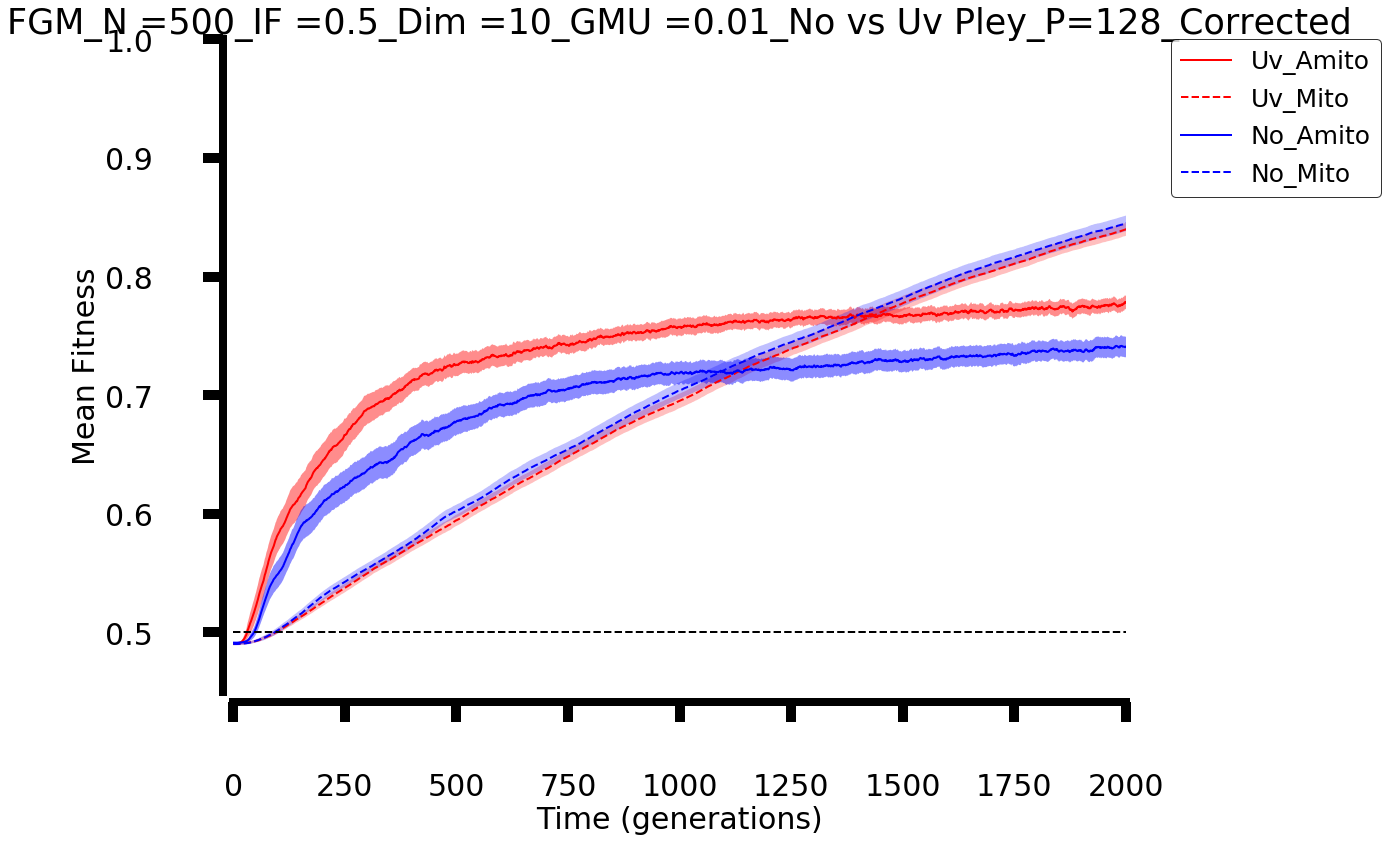

In [30]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,2000)

t = generation_list

i = 8

a1 = amito_fit_mean[i]
error_a1 = list(1.96* np.array(amito_fit_std[i])/((100)**0.5))

a2 = mito_fit_mean[i]
error_a2 = list(1.96* np.array(mito_fit_std[i])/((100)**0.5))


b1 = amito_fit_mean2[i]
error_b1 = list(1.96* np.array(amito_fit_std2[i])/((100)**0.5))

b2 = mito_fit_mean2[i]
error_b2 = list(1.96* np.array(mito_fit_std2[i])/((100)**0.5))


ax.set_title('FGM_N =500_IF =0.5_Dim =10_GMU =0.01_No vs Uv Pley_P=128_Corrected', fontsize =35)
ax.set_xlabel('Time (generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a1,'r', label = 'Uv_Amito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.45, facecolor='r')

ax.plot(t,a2,'r', label = 'Uv_Mito', ls ='--',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.25, facecolor='r')


ax.plot(t,b1,'b', label = 'No_Amito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b1)- np.array(error_b1), np.array(b1)+ np.array(error_b1), alpha =0.45, facecolor='b')

ax.plot(t,b2,'b', label = 'No_Mito', ls ='--',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b2)- np.array(error_b2), np.array(b2)+ np.array(error_b2), alpha =0.25, facecolor='b')



plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')

# extraticks=[0.95]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0.45, 1)



# plt.show()
# plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

### 4. Mean S of Mut Generated Each Gen

In [31]:
def read_file(data):
    with open(data, 'rb') as f:
        x = pickle.load(f)
        
    return x

In [32]:
# Universal pleiotropy

In [33]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181210_Test of FGM_4_Reduce Dim to 10\Data\2.3. Universal Pley_Diff Ploidy_GMU = 0.01\Amito")

In [34]:
amito_f1 = ['Cor_UvPley_GMU001_Dim10_P1_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_UvPley_GMU001_Dim10_P2_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_UvPley_GMU001_Dim10_P4_Amito_MutMeanS_N500_Fit05_SM005', \
           'Cor_UvPley_GMU001_Dim10_P8_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_UvPley_GMU001_Dim10_P16_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_UvPley_GMU001_Dim10_P32_Amito_MutMeanS_N500_Fit05_SM005', \
           'Cor_UvPley_GMU001_Dim10_P45_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_UvPley_GMU001_Dim10_P64_Amito_MutMeanS_N500_Fit05_SM005', \
           'Cor_UvPley_GMU001_Dim10_P128_Amito_MutMeanS_N500_Fit05_SM005']

In [35]:
amito_s1 = []

for i in amito_f1:
    amito_s1.append(read_file(i))

In [36]:
total_amito_s1_mean = []
total_amito_s1_std = []
for i in range(len(amito_s1)):
    amito_sm_mean = []
    amito_sm_std = []
    for j in range(len(amito_s1[0])):
        amito_sm_mean.append(np.nanmean(amito_s1[i][j]))
        amito_sm_std.append(np.nanstd(amito_s1[i][j]))
    
    total_amito_s1_mean.append(amito_sm_mean)
    total_amito_s1_std.append(amito_sm_std)

In [37]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181210_Test of FGM_4_Reduce Dim to 10\Data\2.3. Universal Pley_Diff Ploidy_GMU = 0.01\Mito")

In [38]:
mito_f1 = ['Cor_UvPley_GMU001_Dim10_P1_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_UvPley_GMU001_Dim10_P2_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_UvPley_GMU001_Dim10_P4_Mito_MutMeanS_N500_Fit05_SM005', \
           'Cor_UvPley_GMU001_Dim10_P8_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_UvPley_GMU001_Dim10_P16_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_UvPley_GMU001_Dim10_P32_Mito_MutMeanS_N500_Fit05_SM005', \
           'Cor_UvPley_GMU001_Dim10_P45_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_UvPley_GMU001_Dim10_P64_Mito_MutMeanS_N500_Fit05_SM005', \
           'Cor_UvPley_GMU001_Dim10_P128_Mito_MutMeanS_N500_Fit05_SM005']

In [39]:
mito_s1 = []

for i in mito_f1:
    mito_s1.append(read_file(i))

In [40]:
total_mito_s1_mean = []
total_mito_s1_std = []
for i in range(len(mito_s1)):
    mito_sm_mean = []
    mito_sm_std = []
    for j in range(len(mito_s1[0])):
        mito_sm_mean.append(np.nanmean(mito_s1[i][j]))
        mito_sm_std.append(np.nanstd(mito_s1[i][j]))
    
    total_mito_s1_mean.append(mito_sm_mean)
    total_mito_s1_std.append(mito_sm_std)

In [41]:
generation_list2 = []

for i in range(21):
    generation_list2.append(100*i)
    
print(len(generation_list2))

21


In [42]:
# No pleiotropy

In [43]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181210_Test of FGM_4_Reduce Dim to 10\Data\1.3. No Pley_Diff Ploidy_GMU = 0.01\Amito")

In [44]:
amito_f2 =  ['Cor_NoPley_GMU001_Dim10_P1_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P2_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P4_Amito_MutMeanS_N500_Fit05_SM005', \
           'Cor_NoPley_GMU001_Dim10_P8_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P16_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P32_Amito_MutMeanS_N500_Fit05_SM005', \
           'Cor_NoPley_GMU001_Dim10_P45_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P64_Amito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P128_Amito_MutMeanS_N500_Fit05_SM005']

In [45]:
amito_s2 = []

for i in amito_f2:
    amito_s2.append(read_file(i))

In [46]:
len(amito_s2)

9

In [47]:
len(amito_s2[0])

21

In [48]:
total_amito_s2_mean = []
total_amito_s2_std = []
for i in range(len(amito_s2)):
    mito_sm_mean = []
    mito_sm_std = []
    for j in range(len(amito_s2[0])):
        mito_sm_mean.append(np.nanmean(amito_s2[i][j]))
        mito_sm_std.append(np.nanstd(amito_s2[i][j]))
    
    total_amito_s2_mean.append(mito_sm_mean)
    total_amito_s2_std.append(mito_sm_std)

In [49]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181210_Test of FGM_4_Reduce Dim to 10\Data\1.3. No Pley_Diff Ploidy_GMU = 0.01\Mito")

In [50]:
mito_f2 = ['Cor_NoPley_GMU001_Dim10_P1_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P2_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P4_Mito_MutMeanS_N500_Fit05_SM005', \
           'Cor_NoPley_GMU001_Dim10_P8_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P16_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P32_Mito_MutMeanS_N500_Fit05_SM005', \
           'Cor_NoPley_GMU001_Dim10_P45_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P64_Mito_MutMeanS_N500_Fit05_SM005', 'Cor_NoPley_GMU001_Dim10_P128_Mito_MutMeanS_N500_Fit05_SM005']

In [51]:
mito_s2 = []

for i in mito_f2:
    mito_s2.append(read_file(i))

In [52]:
mito_s2 = []

for i in mito_f2:
    mito_s2.append(read_file(i))

In [53]:
total_mito_s2_mean = []
total_mito_s2_std = []
for i in range(len(mito_s2)):
    mito_sm_mean = []
    mito_sm_std = []
    for j in range(len(mito_s2[0])):
        mito_sm_mean.append(np.nanmean(mito_s2[i][j]))
        mito_sm_std.append(np.nanstd(mito_s2[i][j]))
    
    total_mito_s2_mean.append(mito_sm_mean)
    total_mito_s2_std.append(mito_sm_std)

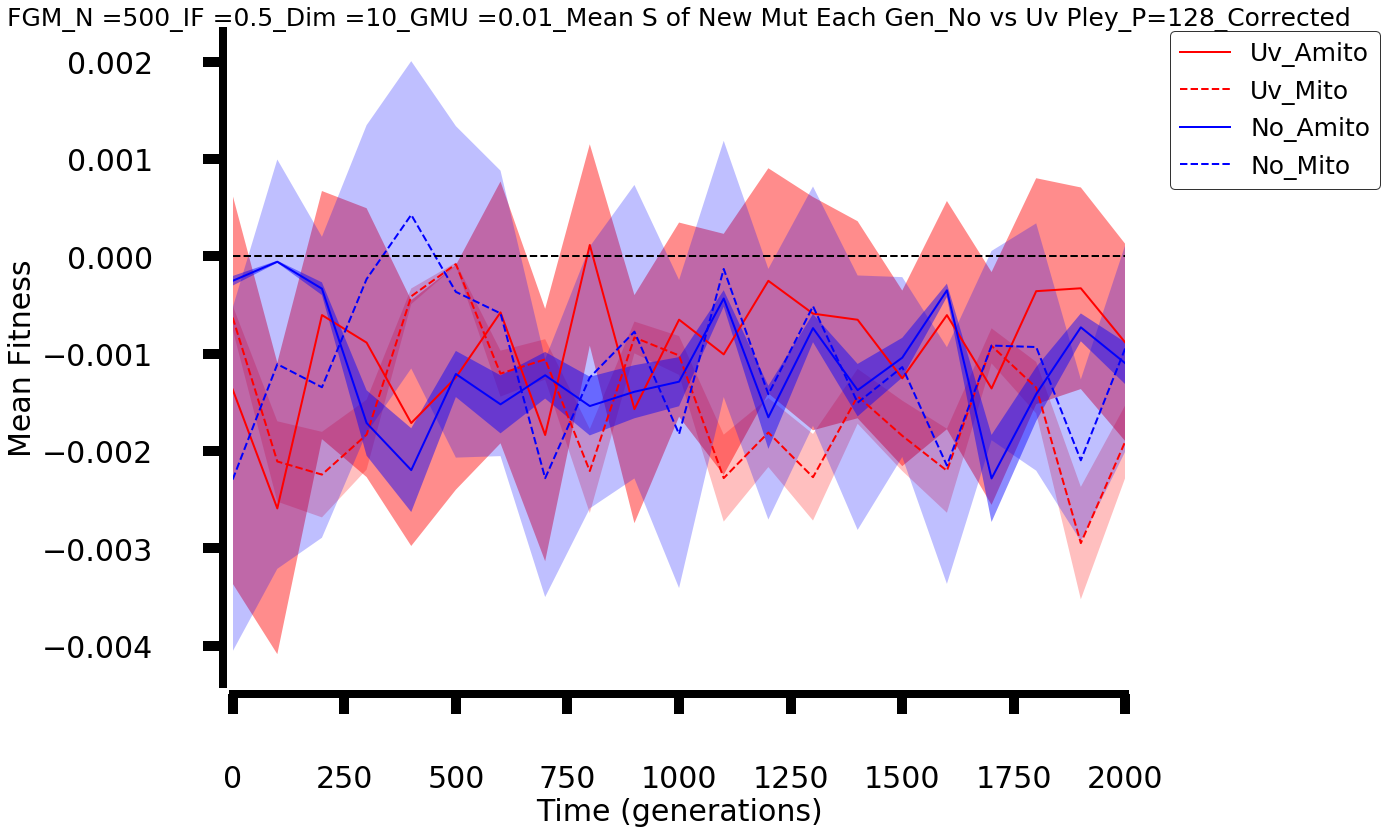

In [64]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,2000)

t = generation_list2

i =8

a1 = total_amito_s1_mean[i]
error_a1 = list(1.96* np.array(total_amito_s1_std[i])/((100)**0.5))

a2 = total_mito_s1_mean[i]
error_a2 = list(1.96* np.array(total_mito_s1_mean[i])/((100)**0.5))


b1 = total_amito_s2_mean[i]
error_b1 = list(1.96* np.array(total_amito_s2_mean[i])/((100)**0.5))

b2 = total_mito_s2_mean[i]
error_b2 = list(1.96* np.array(total_mito_s2_std[i])/((100)**0.5))


ax.set_title('FGM_N =500_IF =0.5_Dim =10_GMU =0.01_Mean S of New Mut Each Gen_No vs Uv Pley_P=128_Corrected', fontsize =25)
ax.set_xlabel('Time (generations)', fontsize =30)
ax.set_ylabel('Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a1,'r', label = 'Uv_Amito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.45, facecolor='r')

ax.plot(t,a2,'r', label = 'Uv_Mito', ls ='--',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.25, facecolor='r')


ax.plot(t,b1,'b', label = 'No_Amito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b1)- np.array(error_b1), np.array(b1)+ np.array(error_b1), alpha =0.45, facecolor='b')

ax.plot(t,b2,'b', label = 'No_Mito', ls ='--',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b2)- np.array(error_b2), np.array(b2)+ np.array(error_b2), alpha =0.25, facecolor='b')



plt.axhline(y=0, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')

# extraticks=[0.95]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

# ax.set_ylim(-0.015, 0.01)



# plt.show()
# plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))